In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
from IPython.core.display import display, HTML
from matplotlib import pyplot as plt
from matplotlib import ticker as mpl_ticker
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmliwqe
interpreter: 3.10.12 (main, Jun 22 2026, 18:55:27) [GCC 11.4.0]
notebook name: 2026-07-25-ecoselfcontext-pgcomplex-screen
notebook path: /home/runner/work/oee4/oee4/binder/2026-07-25-ecoselfcontext-pgcomplex-screen.ipynb
revision: bdac574
timestamp: 2026-08-04T20:57:15Z00:00

IPython==7.16.1
packaging==26.2


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2026-07-25-ecoselfcontext-pgcomplex-screen"


In [5]:
df_all = []
for endeavor in [17, *range(20, 29)]:
    for what, prefix in [
        # ("nobb", f"endeavor={endeavor}/external-competitions/stage=2+what=collated/"),
        ("selfbb", f"endeavor={endeavor}/external-competitions-focalbb/stage=2+what=collated/"),
        ("truebb", f"endeavor={endeavor}/external-competitions-focalbb-true/stage=2+what=collated/"),
    ]:
        s3_handle = boto3.resource(
            's3',
            region_name="us-east-2",
            config=botocore.config.Config(
                signature_version=botocore.UNSIGNED,
            ),
        )
        bucket_handle = s3_handle.Bucket("prq49-20stint")


        competitions = bucket_handle.objects.filter(Prefix=prefix)
        dfs = [
            pd.read_csv(
            f's3://prq49-20stint/{competitions.key}',
            )
            for competitions in competitions
        ]
        print(len(dfs))
        df = pd.concat(dfs, ignore_index=True)
        df["kind"] = what

        df_all.append(df)

df_ecoselfcontext = pd.concat(df_all, ignore_index=True)


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/viz=scatterplot+x=truebb+y=selfbb+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/viz=scatterplot+x=truebb+y=selfbb+ext=.png


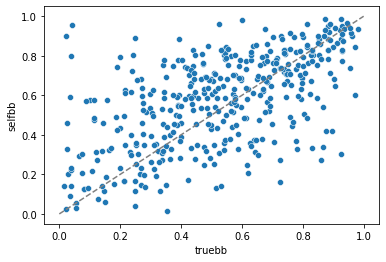

In [6]:
dfx = df_ecoselfcontext.loc[
    (df_ecoselfcontext["Root ID"] == 0),
    ["Competition Series","Focal Prevalence", "kind"],
]
with tp.teed(
    sns.scatterplot,
    data=dfx.groupby(["Competition Series", "kind"]).mean().reset_index().pivot(
        index="Competition Series", columns="kind", values="Focal Prevalence"
    ),
    x="truebb",
    y="selfbb",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.plot([0, 1], [0, 1], ls="--", c="gray")  # Add a diagonal reference line


teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=kind+viz=boxplot+y=focal-prevalence+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=kind+viz=boxplot+y=focal-prevalence+ext=.png


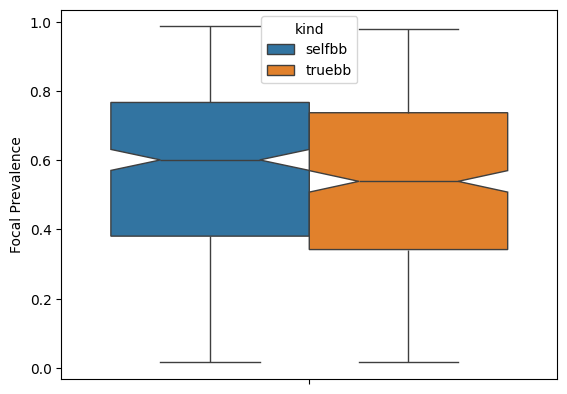

In [7]:
with tp.teed(
    sns.boxplot,
    data=dfx.groupby(["Competition Series", "kind"]).mean().reset_index().astype(
        {"Competition Series": str},
    ),
    y="Focal Prevalence",
    hue="kind",
    notch=True,
    teeplot_subdir=teeplot_subdir,
) as ax:
    pass


# get data


In [8]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49-20stint')

dfs = []
for endeavor in [17, *range(20, 29)]:
    series_profiles, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/series-profiles/stage=8+what=elaborated/',
    )
    df = pd.read_csv(
        f's3://prq49-20stint/{series_profiles.key}',
        compression='xz',
    )
    dfs.append(df)

df_pgcomplex = pd.concat(dfs, ignore_index=True)


# how does fitness complexity change over time?


In [9]:
x = "Flagged Advantageous Sites"
y = "Cardinal Interface Complexity"

data = df_pgcomplex[[x, y, "Series"]].reset_index().dropna()
data["x_quantile"] = data[x].rank(pct=True)
data["y_quantile"] = data[y].rank(pct=True)
data["score"] = data[["x_quantile", "y_quantile"]].min(axis=1)
dft = data.nlargest(
    20,
    "score",
    keep="all"
)
data["target"] = data.index.isin(dft.index)
dft


,index,Flagged Advantageous Sites,Cardinal Interface Complexity,Series,x_quantile,y_quantile,score
103,103,47.0,14.0,21023,0.997475,0.994949,0.994949
28,28,40.0,13.0,17028,0.994949,0.988636,0.988636
105,105,33.0,13.0,21025,0.984848,0.988636,0.984848
152,152,31.0,10.0,22032,0.973485,0.968434,0.968434
380,380,49.0,10.0,28020,1.000000,0.968434,0.968434
356,356,29.0,10.0,27036,0.958333,0.968434,0.958333
77,77,30.0,9.0,20037,0.964646,0.952020,0.952020
133,133,39.0,9.0,22013,0.992424,0.952020,0.952020
134,134,31.0,8.0,22014,0.973485,0.930556,0.930556
338,338,30.0,8.0,27018,0.964646,0.930556,0.930556


teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=target+inner=box+iqr=shade+viz=scatterplot+x=flagged-advantageous-sites+y=cardinal-interface-complexity+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=target+inner=box+iqr=shade+viz=scatterplot+x=flagged-advantageous-sites+y=cardinal-interface-complexity+ext=.png


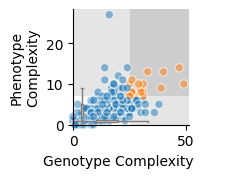

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=target+inner=box+iqr=None+viz=scatterplot+x=flagged-advantageous-sites+y=cardinal-interface-complexity+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=target+inner=box+iqr=None+viz=scatterplot+x=flagged-advantageous-sites+y=cardinal-interface-complexity+ext=.png


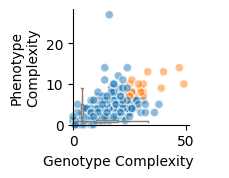

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=target+inner=None+iqr=shade+viz=scatterplot+x=flagged-advantageous-sites+y=cardinal-interface-complexity+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=target+inner=None+iqr=shade+viz=scatterplot+x=flagged-advantageous-sites+y=cardinal-interface-complexity+ext=.png


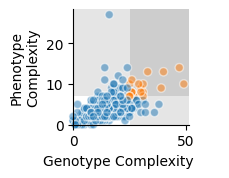

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=target+inner=None+iqr=None+viz=scatterplot+x=flagged-advantageous-sites+y=cardinal-interface-complexity+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/hue=target+inner=None+iqr=None+viz=scatterplot+x=flagged-advantageous-sites+y=cardinal-interface-complexity+ext=.png


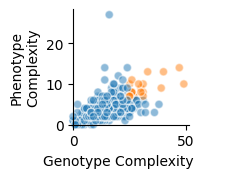

In [10]:
for inner, iqr in it.product(
    (
        "box",
        None,
    ),
    (
        "shade",
        None,
    ),
):
    with tp.teed(
        sns.scatterplot,
        data=data,
        x=x,
        y=y,
        hue="target",
        alpha=0.5,
        clip_on=False,
        legend=False,
        lw=1,
        teeplot_outattrs={
            "inner": inner, "iqr": iqr
        },
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        ax.figure.set_size_inches(1.5, 1.5)
        xlim, ylim = ax.get_xlim()[1], ax.get_ylim()[1]

        q2_x = dft[x].min()
        q2_y = dft[y].min()

        if iqr == "shade":
            # Shade area where x > 2x IQR (vertical span)
            ax.axvspan(
                q2_x,
                ax.get_xlim()[1] * 1.1,
                color="k",
                alpha=0.1,
                zorder=-20,
                linewidth=0
            )
            # # Annotation for X outlier region
            # ax.text(
            #     q2_x * 1.015,
            #     q2_y * 0.5,
            #     r"$>2\times$ IQR",
            #     color="k",
            #     fontsize=7,
            #     ha="left",
            #     va="center",
            #     rotation=90,
            # )

            # Shade area where y > 2x IQR (horizontal span)
            ax.axhspan(
                q2_y,
                ax.get_ylim()[1] * 1.1,
                color="k",
                alpha=0.1,
                zorder=-20,
                linewidth=0
            )
            # # Annotation for Y outlier region
            # ax.text(
            #     q2_x * 0.5,
            #     q2_y,
            #     r"$>2\times$ IQR",
            #     color="k",
            #     fontsize=7,
            #     ha="center",
            #     va="bottom",
            # )

        if inner == "box":
            sns.boxplot(
                data=data,
                x=4,
                y=y,
                ax=ax,
                color="lightgray",
                fliersize=0,
                native_scale=True,
                legend=False,
                width=1.2,
                whis=1.5,
            )
            ax.plot(
                [4, 4],
                [
                   data[y].median(),
                    scipy_stats.iqr(data[y]) * 1 + data[y].quantile(0.5),
                ],
                ls=":",
                color="gray",
                lw=1,
                zorder=-10,
            )
            sns.boxplot(
                data=data,
                x=x,
                y=0.9,
                ax=ax,
                color="lightgray",
                fliersize=0,
                native_scale=True,
                orient="h",
                legend=False,
                width=0.5,
                whis=1.5,
            )
            ax.plot(
                [
                    data[x].median(),
                    scipy_stats.iqr(data[x]) * 1 + data[x].quantile(0.5),
                ],
                [0.9, 0.9],
                ls=":",
                color="gray",
                lw=1,
                zorder=-10,
            )
        # sns.scatterplot(
        #     data=data[data["Series"] == what],
        #     x=x,
        #     y=y,
        #     style="Series",
        #     alpha=0.8,
        #     ax=ax,
        #     clip_on=False,
        #     color="white",
        #     legend=False,
        #     lw=2,
        #     markers=["o"],
        # )
        # sns.scatterplot(
        #     data=data[data["Series"] == what],
        #     x=x,
        #     y=y,
        #     ax=ax,
        #     style="Series",
        #     clip_on=False,
        #     color="tab:blue",
        #     legend=False,
        #     markers=["o"],
        # )
        # sns.scatterplot(
        #     data=data[data["Series"] == what],
        #     x=x,
        #     y=y,
        #     ax=ax,
        #     style="Series",
        #     clip_on=False,
        #     color="white",
        #     legend=False,
        #     markers=["o"],
        #     s=2,
        # )
        ax.set_xlim(left=0, right=xlim)
        ax.set_ylim(bottom=0, top=ylim)
        sns.despine(ax=ax)
        ax.set_ylabel("Phenotype\nComplexity")
        ax.set_xlabel("Genotype Complexity      ")


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/viz=scatterplot+x=truebb+y=selfbb+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/viz=scatterplot+x=truebb+y=selfbb+ext=.png, overwriting it
  warnings.warn(


teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/viz=scatterplot+x=truebb+y=selfbb+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/viz=scatterplot+x=truebb+y=selfbb+ext=.png


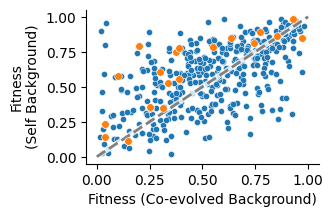

In [11]:

dfx = df_ecoselfcontext.loc[
    (df_ecoselfcontext["Root ID"] == 0),
    ["Competition Series","Focal Prevalence", "kind"],
]
dfx["target"] = dfx["Competition Series"].isin(dft["Series"])
dfp = dfx.groupby(
    ["Competition Series", "kind", "target"],
).mean().reset_index().pivot(
    columns="kind",
    index=["Competition Series", "target"],
    values="Focal Prevalence",
).reset_index()
with tp.teed(
    sns.scatterplot,
    data=dfp[~dfp["target"]],
    x="truebb",
    y="selfbb",
    legend=False,
    s=20,
    zorder=-1,
    teeplot_subdir=teeplot_subdir,
) as ax:
    sns.scatterplot(
        data=dfp[dfp["target"]],
        x="truebb",
        y="selfbb",
        ax=ax,
        legend=False,
        s=30,
        zorder=5,
    )
    ax.set_xlabel("Fitness (Co-evolved Background)")
    ax.set_ylabel("Fitness\n(Self Background)")
    sns.despine(ax=ax)
    ax.figure.set_size_inches(3, 2)  # Set the figure size
    # Add a diagonal reference line
    ax.plot([0, 1], [0, 1], ls="-", lw=4, alpha=0.8, c="white", zorder=4)
    ax.plot([0, 1], [0, 1], ls="--", lw=2, alpha=1.0, c="gray", zorder=4)


In [12]:
plot_df = dfx.groupby(
    ["Competition Series", "kind", "target"],
).mean().reset_index().pivot(
    index=["Competition Series", "target"],
    columns="kind",
    values="Focal Prevalence"
).reset_index()

plot_df["above_line"] = plot_df["selfbb"] > plot_df["truebb"]

# Create a 2x2 contingency table
# Rows: Target (False, True) | Columns: Above Line (False, True)
contingency = pd.crosstab(plot_df["target"], plot_df["above_line"])

display(contingency)
scipy_stats.fisher_exact(contingency)


above_line,False,True
target,,
False,164,216
True,2,18


SignificanceResult(statistic=6.833333333333333, pvalue=0.003978019790900136)

n=10 len(dft)=10


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018])

above_line,False,True
target,,
False,165,225
True,1,9


SignificanceResult(statistic=6.6, pvalue=0.051026398451156724)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=10+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=10+viz=subplots+ext=.png


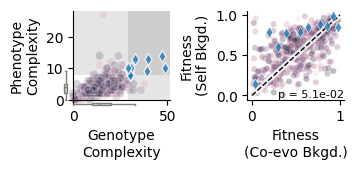

n=20 len(dft)=20


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018, 20021, 24003, 24018, 26018, 20019, 20016, 21036, 24017,
       27028, 28010])

above_line,False,True
target,,
False,164,216
True,2,18


SignificanceResult(statistic=6.833333333333333, pvalue=0.003978019790900136)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=20+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=20+viz=subplots+ext=.png


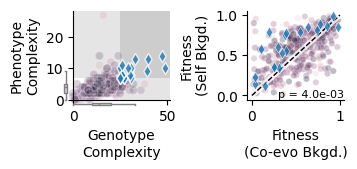

n=30 len(dft)=33


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018, 20021, 24003, 24018, 26018, 20019, 20016, 21036, 24017,
       27028, 28010, 17007, 26037, 27022, 23019, 25037, 27004, 17034,
       20020, 23008, 24024, 25012, 28018, 28023])

above_line,False,True
target,,
False,161,206
True,5,28


SignificanceResult(statistic=4.376699029126214, pvalue=0.0013738043955642569)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=30+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=30+viz=subplots+ext=.png


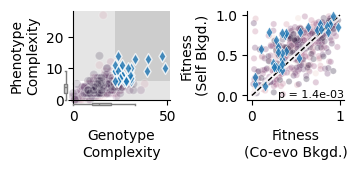

n=10 len(dft)=10


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018])

above_line,False,True
target,,
False,165,225
True,1,9


SignificanceResult(statistic=6.6, pvalue=0.051026398451156724)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=10+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=10+viz=subplots+ext=.png


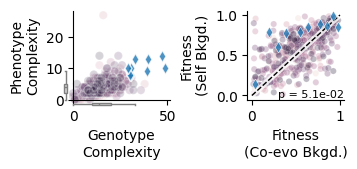

n=20 len(dft)=20


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018, 20021, 24003, 24018, 26018, 20019, 20016, 21036, 24017,
       27028, 28010])

above_line,False,True
target,,
False,164,216
True,2,18


SignificanceResult(statistic=6.833333333333333, pvalue=0.003978019790900136)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=20+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=20+viz=subplots+ext=.png


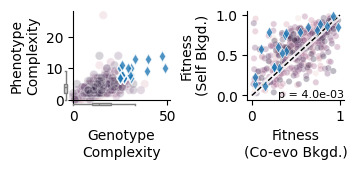

n=30 len(dft)=33


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018, 20021, 24003, 24018, 26018, 20019, 20016, 21036, 24017,
       27028, 28010, 17007, 26037, 27022, 23019, 25037, 27004, 17034,
       20020, 23008, 24024, 25012, 28018, 28023])

above_line,False,True
target,,
False,161,206
True,5,28


SignificanceResult(statistic=4.376699029126214, pvalue=0.0013738043955642569)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=30+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=30+viz=subplots+ext=.png


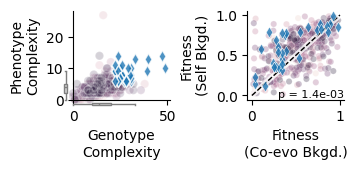

n=10 len(dft)=10


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018])

above_line,False,True
target,,
False,165,225
True,1,9


SignificanceResult(statistic=6.6, pvalue=0.051026398451156724)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=10+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=10+viz=subplots+ext=.png


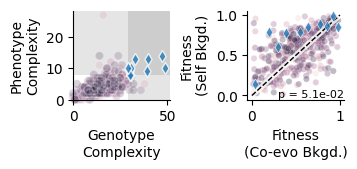

n=20 len(dft)=20


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018, 20021, 24003, 24018, 26018, 20019, 20016, 21036, 24017,
       27028, 28010])

above_line,False,True
target,,
False,164,216
True,2,18


SignificanceResult(statistic=6.833333333333333, pvalue=0.003978019790900136)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=20+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=20+viz=subplots+ext=.png


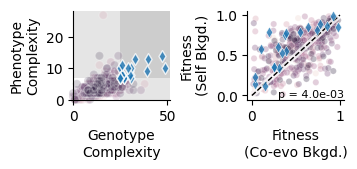

n=30 len(dft)=33


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018, 20021, 24003, 24018, 26018, 20019, 20016, 21036, 24017,
       27028, 28010, 17007, 26037, 27022, 23019, 25037, 27004, 17034,
       20020, 23008, 24024, 25012, 28018, 28023])

above_line,False,True
target,,
False,161,206
True,5,28


SignificanceResult(statistic=4.376699029126214, pvalue=0.0013738043955642569)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=30+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=30+viz=subplots+ext=.png


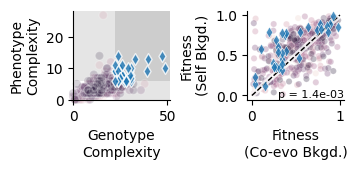

n=10 len(dft)=10


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018])

above_line,False,True
target,,
False,165,225
True,1,9


SignificanceResult(statistic=6.6, pvalue=0.051026398451156724)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=10+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=10+viz=subplots+ext=.png


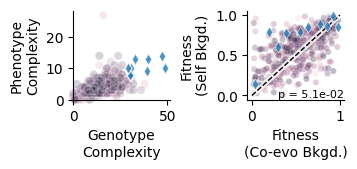

n=20 len(dft)=20


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018, 20021, 24003, 24018, 26018, 20019, 20016, 21036, 24017,
       27028, 28010])

above_line,False,True
target,,
False,164,216
True,2,18


SignificanceResult(statistic=6.833333333333333, pvalue=0.003978019790900136)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=20+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=20+viz=subplots+ext=.png


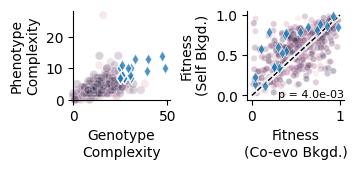

n=30 len(dft)=33


array([21023, 17028, 21025, 22032, 28020, 27036, 20037, 22013, 22014,
       27018, 20021, 24003, 24018, 26018, 20019, 20016, 21036, 24017,
       27028, 28010, 17007, 26037, 27022, 23019, 25037, 27004, 17034,
       20020, 23008, 24024, 25012, 28018, 28023])

above_line,False,True
target,,
False,161,206
True,5,28


SignificanceResult(statistic=4.376699029126214, pvalue=0.0013738043955642569)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=30+viz=subplots+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=30+viz=subplots+ext=.png


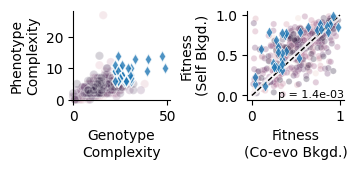

In [13]:
for inner, iqr, n in it.product(
    ["box", None],
    ["shade", None],
    [10, 20, 30],
):
    with tp.teed(
        plt.subplots,
        1,
        2,
        figsize=(3.5, 1.15),
        gridspec_kw={"wspace": 0.8},
        teeplot_outattrs={
            "inner": inner, "iqr": iqr, "n": n,
        },
        teeplot_subdir=teeplot_subdir,
    ) as (fig, (ax1, ax2)):
        x = "Flagged Advantageous Sites"
        y = "Cardinal Interface Complexity"

        data = df_pgcomplex[[x, y, "Series"]].reset_index().dropna()
        data["x_quantile"] = data[x].rank(pct=True)
        data["y_quantile"] = data[y].rank(pct=True)
        data["score"] = data[["x_quantile", "y_quantile"]].min(axis=1)
        dft = data.nlargest(
            n,
            "score",
            keep="all"
        )
        data["target"] = data.index.isin(dft.index)
        print(f"{n=} {len(dft)=}")
        display(dft["Series"].to_numpy())

        sns.scatterplot(
            data=data[data["target"]],
            x=x,
            y=y,
            clip_on=False,
            color="tab:blue",
            marker="d",
            alpha=0.8,
            legend=False,
            lw=1,
            zorder=10,
            ax=ax1,
        )
        sns.scatterplot(
            data=data[~data["target"]],
            x=x,
            y=y,
            hue="Series",
            alpha=0.2,
            clip_on=False,
            legend=False,
            lw=1,
            ax=ax1,
        )
        xlim, ylim = ax1.get_xlim()[1], ax1.get_ylim()[1]

        q2_x = dft[x].min()
        q2_y = dft[y].min()

        if iqr == "shade":
            # Shade area where x > 2x IQR (vertical span)
            ax1.axvspan(
                q2_x,
                ax1.get_xlim()[1] * 1.1,
                color="k",
                alpha=0.1,
                zorder=-20,
                linewidth=0
            )
            # # Annotation for X outlier region
            # ax1.text(
            #     q2_x * 1.015,
            #     q2_y * 0.5,
            #     r"$>2\times$ IQR",
            #     color="k",
            #     fontsize=7,
            #     ha="left",
            #     va="center",
            #     rotation=90,
            # )

            # Shade area where y > 2x IQR (horizontal span)
            ax1.axhspan(
                q2_y,
                ax1.get_ylim()[1] * 1.1,
                color="k",
                alpha=0.1,
                zorder=-20,
                linewidth=0
            )
            # # Annotation for Y outlier region
            # ax1.text(
            #     q2_x * 0.5,
            #     q2_y,
            #     r"$>2\times$ IQR",
            #     color="k",
            #     fontsize=7,
            #     ha="center",
            #     va="bottom",
            # )

        if inner == "box":
            sns.boxplot(
                data=data,
                x=-4,
                y=y,
                ax=ax1,
                color="lightgray",
                fliersize=0,
                native_scale=True,
                legend=False,
                width=1.2,
                whis=1.5,
            )
            sns.boxplot(
                data=data,
                x=x,
                y=-1.5,
                ax=ax1,
                color="lightgray",
                fliersize=0,
                native_scale=True,
                orient="h",
                legend=False,
                width=0.5,
                whis=1.5,
            )
            for artist in ax1.get_children():
                if isinstance(
                    artist,
                    (
                        plt.matplotlib.patches.Patch,
                        plt.matplotlib.lines.Line2D,
                        plt.matplotlib.collections.PathCollection,
                    ),
                ):
                    if artist.get_zorder() == -20:
                        continue
                    artist.set_clip_on(False)
        # sns.scatterplot(
        #     data=data[data["Series"] == what],
        #     x=x,
        #     y=y,
        #     style="Series",
        #     alpha=0.8,
        #     ax=ax,
        #     clip_on=False,
        #     color="white",
        #     legend=False,
        #     lw=2,
        #     markers=["o"],
        # )
        # sns.scatterplot(
        #     data=data[data["Series"] == what],
        #     x=x,
        #     y=y,
        #     ax=ax,
        #     style="Series",
        #     clip_on=False,
        #     color="tab:blue",
        #     legend=False,
        #     markers=["o"],
        # )
        # sns.scatterplot(
        #     data=data[data["Series"] == what],
        #     x=x,
        #     y=y,
        #     ax=ax,
        #     style="Series",
        #     clip_on=False,
        #     color="white",
        #     legend=False,
        #     markers=["o"],
        #     s=2,
        # )
        ax1.set_xlim(left=0, right=xlim)
        ax1.set_ylim(bottom=0, top=ylim)
        sns.despine(ax=ax1)
        ax1.set_ylabel("Phenotype\nComplexity")
        ax1.set_xlabel("Genotype\nComplexity")

        # xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
        dfx = df_ecoselfcontext.loc[
            (df_ecoselfcontext["Root ID"] == 0),
            ["Competition Series","Focal Prevalence", "kind"],
        ]
        dfx["target"] = dfx["Competition Series"].isin(dft["Series"])
        dfp = dfx.groupby(
            ["Competition Series", "kind", "target"],
        ).mean().reset_index().pivot(
            columns="kind",
            index=["Competition Series", "target"],
            values="Focal Prevalence",
        ).reset_index()

        sns.scatterplot(
            data=dfp[~dfp["target"]],
            x="truebb",
            y="selfbb",
            hue="Competition Series",
            ax=ax2,
            legend=False,
            alpha=0.3,
            s=20,
            zorder=-1,
        )
        sns.scatterplot(
            data=dfp[dfp["target"]],
            x="truebb",
            y="selfbb",
            ax=ax2,
            color="tab:blue",
            marker="d",
            alpha=0.8,
            legend=False,
            s=30,
            zorder=5,
        )
        ax2.set_xlabel("Fitness\n(Co-evo Bkgd.)")
        ax2.set_ylabel("Fitness\n(Self Bkgd.)")
        sns.despine(ax=ax2)
        # Add a diagonal reference line
        ax2.plot([0, 1], [0, 1], ls="-", lw=4, alpha=0.8, c="white", zorder=4)
        ax2.plot([0, 1], [0, 1], ls="--", lw=1, alpha=1.0, c="black", zorder=4)

        plot_df = dfx.groupby(
            ["Competition Series", "kind", "target"],
        ).mean().reset_index().pivot(
            index=["Competition Series", "target"],
            columns="kind",
            values="Focal Prevalence"
        ).reset_index()

        plot_df["above_line"] = plot_df["selfbb"] > plot_df["truebb"]

        # Create a 2x2 contingency table
        # Rows: Target (False, True) | Columns: Above Line (False, True)
        contingency = pd.crosstab(plot_df["target"], plot_df["above_line"])
        display(contingency)
        fish = scipy_stats.fisher_exact(contingency)
        display(fish)
        p = fish.pvalue
        ax2.annotate(
            f"p = {p:.1e}",
            xy=(1, 0),
            xycoords="axes fraction",
            ha="right",
            va="bottom",
            fontsize=8,
        )


n=10 len(dft)=11


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036])

above_line,False,True
target,,
False,164,225
True,2,9


SignificanceResult(statistic=3.28, pvalue=0.1319949985489068)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=10+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=10+viz=subplots+what=min+ext=.png


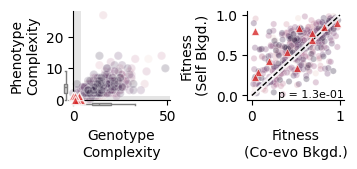

n=20 len(dft)=33


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036, 20028, 27000, 25014, 21002, 23010, 17029, 20009,
       21033, 22027, 23001, 23030, 24001, 24004, 25020, 25022, 25032,
       26006, 26027, 27005, 27006, 27021, 28030])

above_line,False,True
target,,
False,155,212
True,11,22


SignificanceResult(statistic=1.4622641509433962, pvalue=0.36069012148765095)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=20+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=20+viz=subplots+what=min+ext=.png


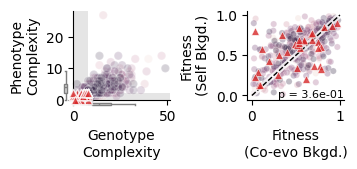

n=30 len(dft)=33


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036, 20028, 27000, 25014, 21002, 23010, 17029, 20009,
       21033, 22027, 23001, 23030, 24001, 24004, 25020, 25022, 25032,
       26006, 26027, 27005, 27006, 27021, 28030])

above_line,False,True
target,,
False,155,212
True,11,22


SignificanceResult(statistic=1.4622641509433962, pvalue=0.36069012148765095)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=30+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=shade+n=30+viz=subplots+what=min+ext=.png


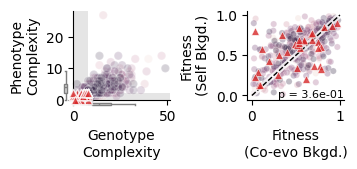

n=10 len(dft)=11


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036])

above_line,False,True
target,,
False,164,225
True,2,9


SignificanceResult(statistic=3.28, pvalue=0.1319949985489068)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=10+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=10+viz=subplots+what=min+ext=.png


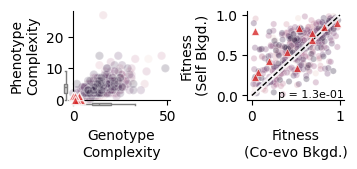

n=20 len(dft)=33


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036, 20028, 27000, 25014, 21002, 23010, 17029, 20009,
       21033, 22027, 23001, 23030, 24001, 24004, 25020, 25022, 25032,
       26006, 26027, 27005, 27006, 27021, 28030])

above_line,False,True
target,,
False,155,212
True,11,22


SignificanceResult(statistic=1.4622641509433962, pvalue=0.36069012148765095)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=20+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=20+viz=subplots+what=min+ext=.png


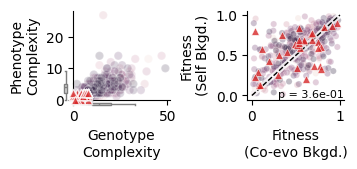

n=30 len(dft)=33


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036, 20028, 27000, 25014, 21002, 23010, 17029, 20009,
       21033, 22027, 23001, 23030, 24001, 24004, 25020, 25022, 25032,
       26006, 26027, 27005, 27006, 27021, 28030])

above_line,False,True
target,,
False,155,212
True,11,22


SignificanceResult(statistic=1.4622641509433962, pvalue=0.36069012148765095)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=30+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=box+iqr=None+n=30+viz=subplots+what=min+ext=.png


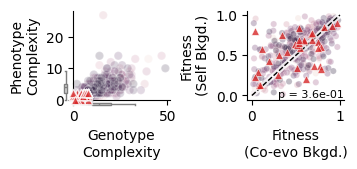

n=10 len(dft)=11


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036])

above_line,False,True
target,,
False,164,225
True,2,9


SignificanceResult(statistic=3.28, pvalue=0.1319949985489068)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=10+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=10+viz=subplots+what=min+ext=.png


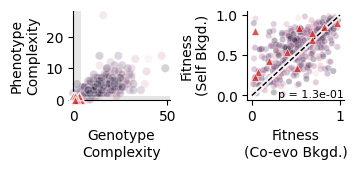

n=20 len(dft)=33


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036, 20028, 27000, 25014, 21002, 23010, 17029, 20009,
       21033, 22027, 23001, 23030, 24001, 24004, 25020, 25022, 25032,
       26006, 26027, 27005, 27006, 27021, 28030])

above_line,False,True
target,,
False,155,212
True,11,22


SignificanceResult(statistic=1.4622641509433962, pvalue=0.36069012148765095)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=20+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=20+viz=subplots+what=min+ext=.png


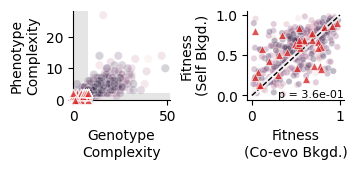

n=30 len(dft)=33


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036, 20028, 27000, 25014, 21002, 23010, 17029, 20009,
       21033, 22027, 23001, 23030, 24001, 24004, 25020, 25022, 25032,
       26006, 26027, 27005, 27006, 27021, 28030])

above_line,False,True
target,,
False,155,212
True,11,22


SignificanceResult(statistic=1.4622641509433962, pvalue=0.36069012148765095)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=30+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=shade+n=30+viz=subplots+what=min+ext=.png


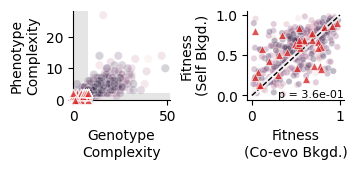

n=10 len(dft)=11


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036])

above_line,False,True
target,,
False,164,225
True,2,9


SignificanceResult(statistic=3.28, pvalue=0.1319949985489068)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=10+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=10+viz=subplots+what=min+ext=.png


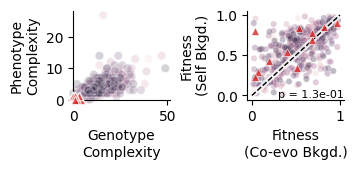

n=20 len(dft)=33


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036, 20028, 27000, 25014, 21002, 23010, 17029, 20009,
       21033, 22027, 23001, 23030, 24001, 24004, 25020, 25022, 25032,
       26006, 26027, 27005, 27006, 27021, 28030])

above_line,False,True
target,,
False,155,212
True,11,22


SignificanceResult(statistic=1.4622641509433962, pvalue=0.36069012148765095)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=20+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=20+viz=subplots+what=min+ext=.png


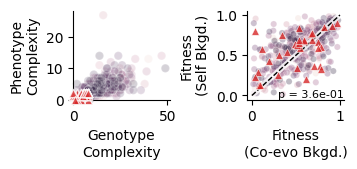

n=30 len(dft)=33


array([20023, 21009, 25001, 28028, 26023, 20031, 21037, 17001, 24026,
       26000, 26036, 20028, 27000, 25014, 21002, 23010, 17029, 20009,
       21033, 22027, 23001, 23030, 24001, 24004, 25020, 25022, 25032,
       26006, 26027, 27005, 27006, 27021, 28030])

above_line,False,True
target,,
False,155,212
True,11,22


SignificanceResult(statistic=1.4622641509433962, pvalue=0.36069012148765095)

teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=30+viz=subplots+what=min+ext=.pdf
teeplots/2026-07-25-ecoselfcontext-pgcomplex-screen/inner=None+iqr=None+n=30+viz=subplots+what=min+ext=.png


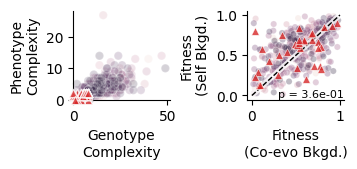

In [14]:
for inner, iqr, n in it.product(
    ["box", None],
    ["shade", None],
    [10, 20, 30],
):
    with tp.teed(
        plt.subplots,
        1,
        2,
        figsize=(3.5, 1.15),
        gridspec_kw={"wspace": 0.8},
        teeplot_outattrs={
            "inner": inner, "iqr": iqr, "n": n, "what": "min",
        },
        teeplot_subdir=teeplot_subdir,
    ) as (fig, (ax1, ax2)):
        x = "Flagged Advantageous Sites"
        y = "Cardinal Interface Complexity"

        data = df_pgcomplex[[x, y, "Series"]].reset_index().dropna()
        data["x_quantile"] = data[x].rank(pct=True)
        data["y_quantile"] = data[y].rank(pct=True)

        # CHANGED: Use max to find points that are low on BOTH axes
        data["score"] = data[["x_quantile", "y_quantile"]].max(axis=1)
        # CHANGED: Pull the smallest scores instead of largest
        dft = data.nsmallest(
            n,
            "score",
            keep="all"
        )
        print(f"{n=} {len(dft)=}")
        display(dft["Series"].to_numpy())
        data["target"] = data.index.isin(dft.index)

        sns.scatterplot(
            data=data[data["target"]],
            x=x,
            y=y,
            clip_on=False,
            color="tab:red",
            marker="^",
            alpha=0.8,
            legend=False,
            lw=1,
            zorder=10,
            ax=ax1,
        )
        sns.scatterplot(
            data=data[~data["target"]],
            x=x,
            y=y,
            hue="Series",
            alpha=0.2,
            clip_on=False,
            legend=False,
            lw=1,
            ax=ax1,
        )
        xlim, ylim = ax1.get_xlim()[1], ax1.get_ylim()[1]

        # CHANGED: Find the upper boundary of these bottom n points
        q2_x = dft[x].max()
        q2_y = dft[y].max()

        if iqr == "shade":
            # CHANGED: Shade area from 0 up to the bounding max of the bottom set
            ax1.axvspan(
                ax1.get_xlim()[0],
                q2_x,
                color="k",
                alpha=0.1,
                zorder=-20,
                linewidth=0
            )
            # # Annotation for X outlier region
            # ax1.text(
            #     q2_x * 1.015,
            #     q2_y * 0.5,
            #     r"$>2\times$ IQR",
            #     color="k",
            #     fontsize=7,
            #     ha="left",
            #     va="center",
            #     rotation=90,
            # )

            # CHANGED: Shade area from 0 up to the bounding max of the bottom set
            ax1.axhspan(
                ax1.get_ylim()[0],
                q2_y,
                color="k",
                alpha=0.1,
                zorder=-20,
                linewidth=0
            )
            # # Annotation for Y outlier region
            # ax1.text(
            #     q2_x * 0.5,
            #     q2_y,
            #     r"$>2\times$ IQR",
            #     color="k",
            #     fontsize=7,
            #     ha="center",
            #     va="bottom",
            # )

        if inner == "box":
            sns.boxplot(
                data=data,
                x=-4,
                y=y,
                ax=ax1,
                color="lightgray",
                fliersize=0,
                native_scale=True,
                legend=False,
                width=1.2,
                whis=1.5,
            )
            sns.boxplot(
                data=data,
                x=x,
                y=-1.5,
                ax=ax1,
                color="lightgray",
                fliersize=0,
                native_scale=True,
                orient="h",
                legend=False,
                width=0.5,
                whis=1.5,
            )
            for artist in ax1.get_children():
                if isinstance(
                    artist,
                    (
                        plt.matplotlib.patches.Patch,
                        plt.matplotlib.lines.Line2D,
                        plt.matplotlib.collections.PathCollection,
                    ),
                ):
                    if artist.get_zorder() == -20:
                        continue
                    artist.set_clip_on(False)

        ax1.set_xlim(left=0, right=xlim)
        ax1.set_ylim(bottom=0, top=ylim)
        sns.despine(ax=ax1)
        ax1.set_ylabel("Phenotype\nComplexity")
        ax1.set_xlabel("Genotype\nComplexity")

        # xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
        dfx = df_ecoselfcontext.loc[
            (df_ecoselfcontext["Root ID"] == 0),
            ["Competition Series","Focal Prevalence", "kind"],
        ]
        dfx["target"] = dfx["Competition Series"].isin(dft["Series"])
        dfp = dfx.groupby(
            ["Competition Series", "kind", "target"],
        ).mean().reset_index().pivot(
            columns="kind",
            index=["Competition Series", "target"],
            values="Focal Prevalence",
        ).reset_index()

        sns.scatterplot(
            data=dfp[~dfp["target"]],
            x="truebb",
            y="selfbb",
            hue="Competition Series",
            ax=ax2,
            legend=False,
            alpha=0.3,
            s=20,
            zorder=-1,
        )
        sns.scatterplot(
            data=dfp[dfp["target"]],
            x="truebb",
            y="selfbb",
            ax=ax2,
            color="tab:red",
            marker="^",
            alpha=0.8,
            legend=False,
            s=30,
            zorder=5,
        )
        ax2.set_xlabel("Fitness\n(Co-evo Bkgd.)")
        ax2.set_ylabel("Fitness\n(Self Bkgd.)")
        sns.despine(ax=ax2)
        # Add a diagonal reference line
        ax2.plot([0, 1], [0, 1], ls="-", lw=4, alpha=0.8, c="white", zorder=4)
        ax2.plot([0, 1], [0, 1], ls="--", lw=1, alpha=1.0, c="black", zorder=4)

        plot_df = dfx.groupby(
            ["Competition Series", "kind", "target"],
        ).mean().reset_index().pivot(
            index=["Competition Series", "target"],
            columns="kind",
            values="Focal Prevalence"
        ).reset_index()

        plot_df["above_line"] = plot_df["selfbb"] > plot_df["truebb"]

        # Create a 2x2 contingency table
        # Rows: Target (False, True) | Columns: Above Line (False, True)
        contingency = pd.crosstab(plot_df["target"], plot_df["above_line"])
        display(contingency)
        fish = scipy_stats.fisher_exact(contingency)
        display(fish)
        p = fish.pvalue
        ax2.annotate(
            f"p = {p:.1e}",
            xy=(1, 0),
            xycoords="axes fraction",
            ha="right",
            va="bottom",
            fontsize=8,
        )
